# 1. Facebook Artist Page Network (2017)

This notebook includes a comprehensive analysis of a Facebook artist pages network, sourced from the Network Data Repository (Rossi & Ahmed, 2015). The dataset was originally introduced by Rozemberczki et al. (2019) and consists of 819,096 connections between 50,492 nodes. It is represented as an edge list where each row is a mutual like between two artists. This setup provides a structured view of the global music industry on Facebook, potentially revealing community formations, an artist's influence within clusters, and more. The notebook attempts to identify and reveal such structures by applying a series of graph analytics functions from the igraph package in R, accompanied by visual representations of the extracted data.

List of igraph functions used in this notebook:

- `graph_from_data_frame()`
- `vcount()`
- `ecount()`
- `edge_density()`
- `degree()`
- `delete_vertices()`
- `coreness()`
- `eigen_centrality()`
- `page_rank()`
- `assortativity_degree()`
- `cluster_louvain()`
- `hits_scores()`
- `constraint()`
- `edge_connectivity()`
- `bridges()`
- `vertex_connectivity()`
- `mean_distance()`
- `diameter()`
- `betweenness()`
- `similarity()`

# 2. Importing packages

In [38]:
# Importing libarires 

library("igraph")

## Reading input files
The dataset is loaded from two files - an edge list and a node list. The node identifiers are aligned with the edge list using the `new_id` column, and 23 edges referencing unlisted nodes are removed to ensure consistency. The graph is then constructed as an undirected network using igraph's `graph_from_data_frame()`, with artist names attached as node labels.

In [43]:
# Reading the graph from the file into an edge list
edges <- read.csv("./data/fb-pages-artist.edges", header = FALSE, col.names = c("from", "to"))
nodes <- read.csv("./data/fb-pages-artist.nodes", header = TRUE)

nodes$new_id <- as.character(nodes$new_id)
edges$from <- as.character(edges$from)
edges$to <- as.character(edges$to)

# Removing edges where either endpoint is missing from nodes
valid_ids <- nodes$new_id
edges <- edges[edges$from %in% valid_ids & edges$to %in% valid_ids,]

# Creating the graph from the edge list
g <- graph_from_data_frame(edges, directed = FALSE, vertices = nodes[, c("new_id", "name")])


# 3. Graph Simplification
Because the original Facebook artist network contains more than **50,000 nodes and 819,000 edges**, some graph analytics tasks become computationally expensive and difficult to interpret visually. Therefore, the graph was simplified before performing the analyses in Task 5

In [47]:
# Original graph statistics
orig_vertices <- igraph::vcount(g)
orig_edges <- igraph::ecount(g)

# Compute degree for each node using igraph
deg <- igraph::degree(g)

# Simplify graph by keeping nodes with degree > 50
g <- igraph::induced_subgraph(g, vids = igraph::V(g)[deg > 50])

# Print comparison statistics
cat("Original Vertices:", orig_vertices, "\n")
cat("Original Edges:", orig_edges, "\n\n")

cat("Vertices (after simplification):", igraph::vcount(g), "\n")
cat("Edges (after simplification):", igraph::ecount(g), "\n")
cat("Density:", igraph::edge_density(g), "\n")
cat("Maximum degree:", max(igraph::degree(g)), "\n")
cat("Average degree:", round(mean(igraph::degree(g)), 2), "\n")
cat("Minimum degree:", min(igraph::degree(g)), "\n")

Original Vertices: 50492 
Original Edges: 819096 

Vertices (after simplification): 8441 
Edges (after simplification): 359376 
Density: 0.01008887 
Maximum degree: 807 
Average degree: 85.15 
Minimum degree: 3 


# 5. Graph Analytics
The goal is to identify important nodes, structural patterns, and communities within the graph using igraph and related graph analysis techniques.

### (a) Central Nodes
**Degree centrality** measures how many connections each node has.
Nodes with high degree values are considered central nodes, because they connect to many other nodes in the network.
In this dataset, such nodes may represent **highly influential or widely connected artist pages** within the Facebook network.

In [51]:
# Compute degree centrality using igraph
centrality <- igraph::degree(g)

# Get top 10 nodes
top_nodes <- sort(centrality, decreasing = TRUE)[1:10]

# Convert to a clean table
top_nodes_df <- data.frame(
  Artist = names(top_nodes),
  Degree = as.numeric(top_nodes)
)

top_nodes_df

Artist,Degree
<chr>,<dbl>
Calvin Harris,807
Yuna Alvara,799
Diplo,797
Taylor Swift,796
Beyoncé,785
Skrillex,780
Daft Punk,746
Hardwell,742
Jonny Zywiciel,725


The output shows the 10 artist pages with the highest number of connections in the network.
These nodes act as ***hubs***, linking many other artists.

## (b) Longest Path
The **diameter** of a graph represents the longest shortest path between any two nodes in the network.
It provides insight into the **maximum distance between artists** within the network.

In [52]:
# Calculate the diameter of the network
diameter_value <- diameter(g)

diameter_value

[1] 5

The diameter indicates ***the largest number of steps required to travel between two artists*** in the network.

In [53]:
# Retrieve the vertices that form the longest path
longest_path <- get_diameter(g)

longest_path

+ 6/8441 vertices, named, from ea4ce96:
[1] ONNO              IVAN MASA         Nicky Romero      Drops            
[5] Shruti Haasan     Times Music South

The notation ***+ 6/8441 vertices*** indicates that the path contains **6 nodes out of the total 8441 nodes** in the graph. The path starts with ONNO and ends with Times Music South, passing through several intermediate artists such as  IVAN MASA, Nicky Romer, Drops,Shruti Haasan. Since this path contains 6 nodes, the number of edges between them is 5, which corresponds to the previously computed ***graph diameter of 5***. This means that these two artists are among the most distant nodes in the network

## (c) Largest Clique
A **clique** is a group of nodes where every node is connected to every other node.
Large cliques indicate tightly connected groups of artists who interact frequently.

The result represents ***a fully connected group of artist pages***, where each artist is directly connected to every other artist in the group.

In [54]:
# Identify the largest fully connected groups in the network
largest_cliques_list <- largest_cliques(g)

# Show the size of the largest clique
length(largest_cliques_list[[1]])

# Display the first largest clique
largest_cliques_list[[1]]

[1] 18

+ 18/8441 vertices, named, from ea4ce96:
 [1] Saphera          Degos & Re-Done  The Vision       Bass Chaserz    
 [5] Krowdexx         Zatox            The Pitcher      Digital Mindz   
 [9] Omegatypez       Scope DJ         Toneshifterz     Noisecontrollers
[13] Da Tweekaz       Code Black       Wasted Penguinz  Adrenalize      
[17] Headhunterz      Wildstylez      

The output above shows one of the largest cliques detected in the network, containing ***18 nodes out of 8441***.

### (d) Ego Networks
An **ego network** represents a node and its immediate neighbors.
It helps analyze the **local structure** around a specific artist.

In [58]:
ego_node <- names(top_nodes)[1]
ego_node

[1] "Calvin Harris"

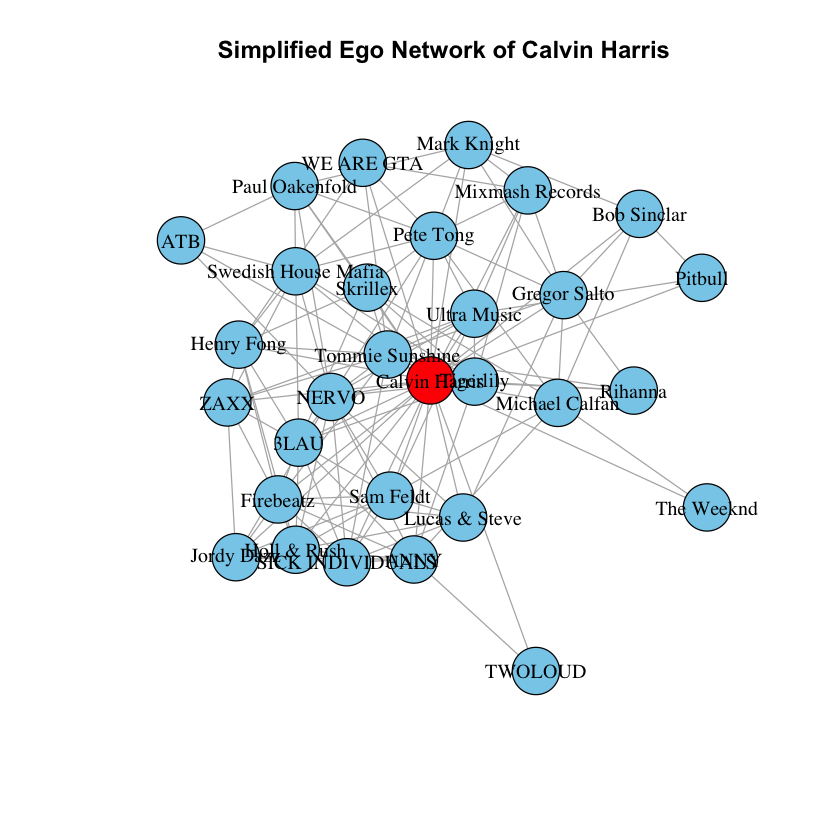

In [59]:
# Get ego nodes
ego_nodes <- igraph::ego(g, order = 1, nodes = ego_node)[[1]]

# Create ego subgraph
ego_graph <- igraph::induced_subgraph(g, ego_nodes)

# Keep only the top 30 nodes by degree
deg <- igraph::degree(ego_graph)
top30 <- names(sort(deg, decreasing = TRUE))[1:30]

ego_graph_small <- igraph::induced_subgraph(ego_graph, top30)

# Highlight ego node
igraph::V(ego_graph_small)$color <- ifelse(igraph::V(ego_graph_small)$name == ego_node, "red", "skyblue")

# Plot the graph
plot(
  ego_graph_small,
  layout = igraph::layout_with_fr(ego_graph_small),
  vertex.size = 18,
  vertex.label.cex = 1,
  vertex.label.color = "black",
  edge.color = "gray70",
  main = paste("Simplified Ego Network of", ego_node)
)

The original ego network contained over ***800 nodes (as seen from a Central Nodes section result for this artist)*** due to the high degree of the central node (Calvin Harris). To improve visualization clarity, the network was simplified by keeping only the most connected neighboring nodes, which allowed us a clearer representation of the local network structure while preserving the most significant relationships.

The ego network represents a node and all nodes directly connected to it. In this case, the ego network of the most connected artist shows the local structure surrounding that artist, illustrating how their page is linked to many other artist pages in the network.

## (e) Power Centrality
**Power centrality** measures a node’s influence by considering both **its connections and the importance of its neighbors**.
Nodes connected to other influential nodes will have **higher** power centrality scores.

In [60]:
install.packages("sna", repos = "https://cloud.r-project.org")
install.packages("intergraph", repos = "https://cloud.r-project.org")


The downloaded binary packages are in
	/var/folders/63/_r7r_q790t169z5lg0ffd84r0000gn/T//Rtmp4PhnNW/downloaded_packages

The downloaded binary packages are in
	/var/folders/63/_r7r_q790t169z5lg0ffd84r0000gn/T//Rtmp4PhnNW/downloaded_packages


In [ ]:
library(intergraph)
detach("package:sna", unload = TRUE)
detach("package:network", unload = TRUE)

In [65]:
# Compute power centrality
power_cent <- igraph::power_centrality(g)

# Extract top 10 nodes
top_power_nodes <- sort(power_cent, decreasing = TRUE)[1:10]

# Convert to a table
top_power_df <- data.frame(
  Artist = names(top_power_nodes),
  PowerCentrality = as.numeric(top_power_nodes)
)

top_power_df

Artist,PowerCentrality
<chr>,<dbl>
ROCKY HORROR F. S.,4.110516
Ludovico Einaudi,3.839900
matthew gray gubler (as official as it gets)!,3.618317
Crywolf,3.588475
Avi Avital,3.544492
Mark Tarmonea,3.518184
Kristin Chenoweth,3.375755
Cedric Tylleman,3.365812
Damien Lawson,3.319659


From this result, the artists listed in the table, such as ROCKY HORROR F. S., Ludovico Einaudi, and Crywolf—have the highest structural influence in our graph. This means they are positioned in parts of the network where they are connected to other well-connected artists, allowing them to act as important connectors within the network structure.

Nodes with high power centrality are ***important connectors in the network***, often linking influential artist communities.

## (f) Community Detection
Communities represent groups of nodes that are **more densely connected to each other than to the rest of the network**.

The **Louvain algorithm** is used to detect communities efficiently in large graphs.

Here we shall stop for a moment and explore the logiv behind this algorithm. As mentioned above, a community is a group of nodes that are **more densely connected to each other than to the rest of the network**. The algorithm identifies these groups by maximizing **modularity**, a measure that evaluates how well the network is divided into communities. Higher modularity values indicate stronger community structure.
The algorithm works iteratively in two main phases. First, each node is initially placed in its own community. Then, the algorithm repeatedly moves nodes to neighboring communities if doing so increases modularity. Once no node movement can further improve modularity, communities are aggregated into single nodes, forming a smaller network. The process is then repeated on this reduced graph until no further modularity improvement is possible. This hierarchical approach makes our **Louvain algorithm** efficient and particularly suitable for large graphs such as the Facebook artist network analyzed in this notebook.

In [69]:
# Detect communities using the Louvain algorithm
communities <- igraph::cluster_louvain(g)

# Number of detected communities
length(communities)

# Community membership of each node
membership_vec <- igraph::membership(communities)

# Cinverting result to table for better visualization
membership_df <- data.frame(
  Artist = names(membership_vec),
  Community = as.numeric(membership_vec)
)

# Show first 10 rows
head(membership_df, 10)

[1] 11

,Artist,Community
,<chr>,<dbl>
1,Silent Descent,1
2,Arctic Monkeys,1
3,Township Rebellion,2
4,Laser The Band,3
5,Recondite,2
6,ONNO,2
7,BARE,4
8,DJPreacher,2
9,DJ Steve Lawler,2


The table shows the community assignment for each artist detected by the algorithm. Artists with the same community number belong to the same cluster of closely connected nodes in the network.

In [70]:
# Compute community sizes
community_sizes <- igraph::sizes(communities)

# Convert to table
community_sizes_df <- data.frame(
  Community = seq_along(community_sizes),
  Size = as.numeric(community_sizes)
)

# Sort by largest community
community_sizes_df <- community_sizes_df[order(-community_sizes_df$Size), ]

community_sizes_df

,Community,Size
,<int>,<dbl>
1,1,2162
5,5,1791
2,2,1371
6,6,1120
4,4,922
9,9,335
8,8,180
7,7,171
3,3,168


We can observe the size of each ***detected community***, meaning ***how many artists belong to each cluster*** in the network. Larger communities (community 1 and 5) contain more strongly interconnected artists, while smaller communities represent more specialized or niche groups.

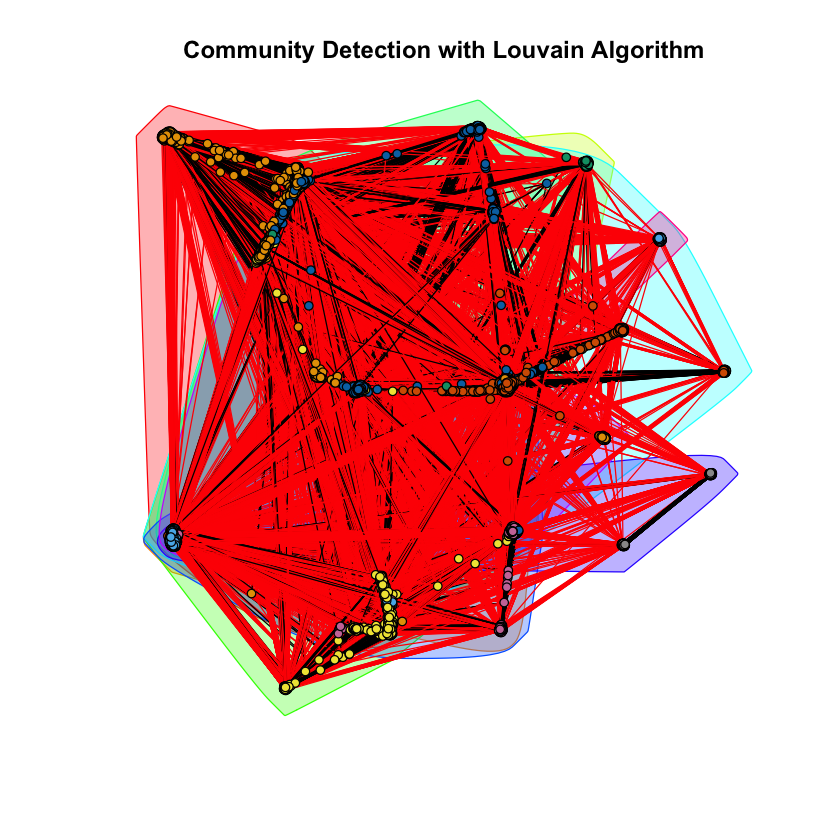

In [68]:
plot(
  communities,
  g,
  vertex.size = 3,
  vertex.label = NA,
  main = "Community Detection with Louvain Algorithm"
)

This initial visualization appears dense due to the large number of nodes and edges in the graph. This is a common issue in large-scale networks, where many overlapping edges produced a cluttered structure. Thus, we will take first 100 nodes for better visualization purpose:

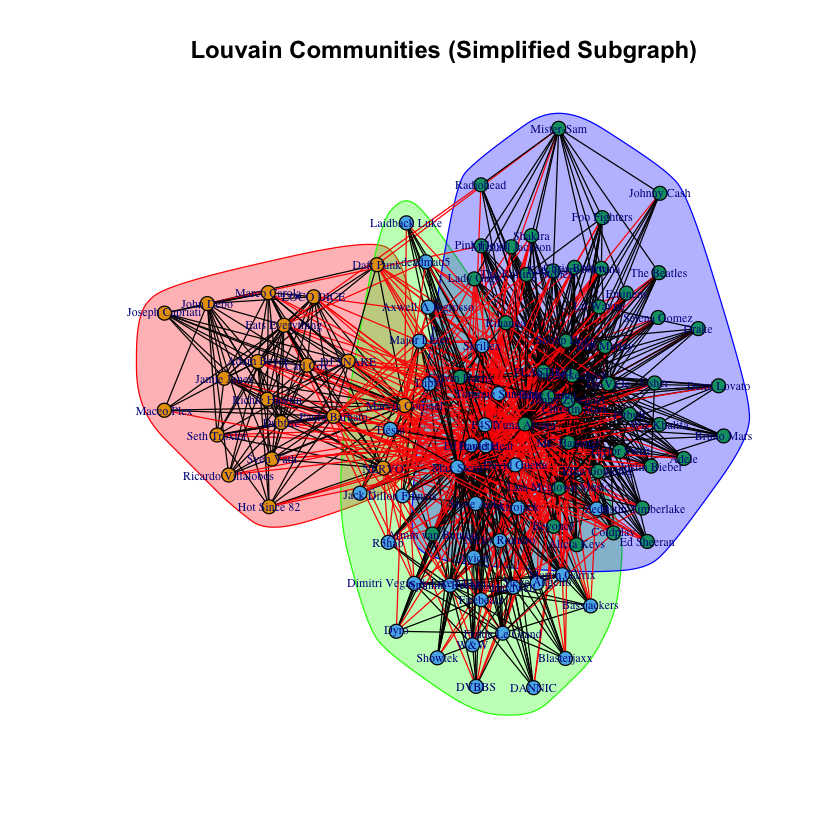

In [72]:
# Take 100 nodes from the largest communities for visualization
top_nodes_comm <- names(sort(igraph::degree(g), decreasing = TRUE))[1:100]
g_vis <- igraph::induced_subgraph(g, top_nodes_comm)

comm_vis <- igraph::cluster_louvain(g_vis)

plot(
  comm_vis,
  g_vis,
  vertex.size = 5,
  vertex.label.cex = 0.6,
  main = "Louvain Communities (Simplified Subgraph)"
)

The plot visualizes the communities identified by the Louvain algorithm, where each color represents a cluster of closely connected artist pages in the network.

Community detection helps identify ***clusters of artist pages that are closely related***, possibly representing ***shared audiences, genres, or collaborations***.

## Summary for this section
Overall, in this section, our graph analysis aims to highlight the presence of ***highly connected hub nodes, tightly connected groups (cliques), and community structures*** within the Facebook artist network.